In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from nn import Linear, ReLU, Logistic, Tanh, Softmax, SGDWithMomentum, BCEWithLogitsLoss, Tensor, Sequential

In [3]:
X_train = Tensor(np.array([[0, 0], [0, 1], [1, 0], [1, 1]]).astype(np.float32))
Y_train = Tensor(np.array([[0], [1], [1], [0]]).astype(np.float32))

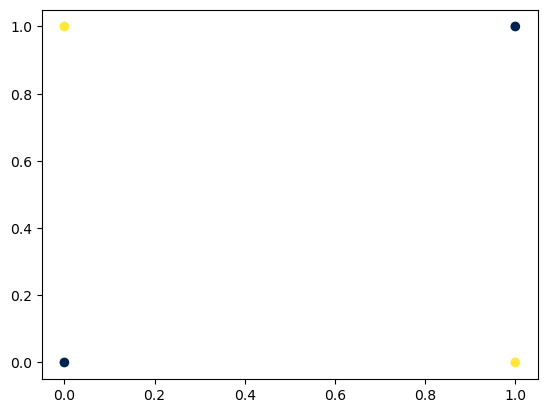

In [13]:
plt.scatter(X_train[:,0], X_train[:,1], c=Y_train[:,0], cmap="cividis", vmin=0, vmax=1);

In [14]:
model = Sequential([
    Linear(2, 2),
    Tanh(),
    Linear(2, 1)
])

In [15]:
def batch(n, batch_size=128):
    indices = np.array(range(n))
    np.random.shuffle(indices)
    i = 0
    while i < n:
        yield indices[i: i + batch_size]
        i += batch_size

In [16]:
optim = SGDWithMomentum(model.parameters(), learning_rate=0.01, beta1=0.9)
loss = BCEWithLogitsLoss()

In [17]:
epochs = 10000
batch_size = 1

# Boucle sur les époques
for i in range(epochs):

    # Boucle sur les batchs
    for indices in batch(X_train.shape[0], batch_size):

        # Données d'entraînement pour le batch
        X_ = X_train[indices]
        Y_ = Y_train[indices]

        # Passe avant
        Yhat_ = model.forward(X_)
        mse = loss(Yhat_, Y_)

        # Rétro-propagation
        grad = loss.backward()
        model.backward(grad)

        # Optimisation
        optim.step()

In [18]:
model[0].weight, model[0].bias, model[2].weight, model[2].bias

(array([[2.6258571 , 3.71289422],
        [2.61602637, 3.64750906]]),
 array([[-3.83621685, -1.74114248]]),
 array([[-5.47296521],
        [ 5.36466731]]),
 array([[-4.79027996]]))

In [11]:
clf = Sequential([model, Logistic()])

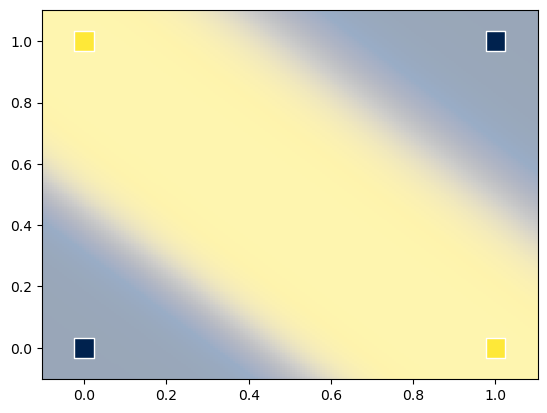

In [27]:
# Résolution de la grille
s = 200

X1, X2 = np.meshgrid(np.linspace(-0.1, 1.1, s), np.linspace(-0.1, 1.1, s))

# Calcul
Xi = np.stack((X1.ravel(), X2.ravel())).T
Yi = clf(Tensor(Xi)).reshape(s, s)

# Visualisation
plt.pcolormesh(X1, X2, Yi, cmap='cividis', alpha=0.4, shading='auto')
plt.scatter(X_train.data[:,0], X_train.data[:,1], c=Y_train, marker="s", cmap='cividis', edgecolor="w", s=200)
# plt.title("Frontière de décision");